In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import zscore
from scipy.stats import spearmanr
from sklearn.decomposition import FactorAnalysis
sns.set(style='ticks', font_scale=1.)
df = pd.read_csv('../data/datalist.csv', index_col=0)
%matplotlib inline

## Loading data

In [2]:
ind = 6
row = df.iloc[ind]
save_root = row['save_root']

baseline_ = np.load(save_root + 'cell_dff.npz', allow_pickle=True)['baseline'].astype('float16')
A_center = np.load(save_root+'cell_center.npy')
brain_map = np.load(save_root+'Y_ave.npy').astype('float')
_ = np.load(save_root+'baseline_clusters.npz', allow_pickle=True)
invalid_ = _['invalid_']
ev_thres = _['ev_thres']
cell_cluster = _['cell_cluster']
baseline_ = baseline_[~invalid_][ev_thres]
A_center = A_center[~invalid_][ev_thres]

_ = np.load(save_root+'baseline_subclusters.npz', allow_pickle=True)
cell_subcluster = _['cell_subcluster'] # cluster label
cell_subcluster_mat = _['cell_subcluster_mat']
p_oxy = _['p_oxy']
r_oxy = _['r_oxy'] # cluster correlation with oxygen kernel

## Ploting cells in a subpopulation and its dynamcis

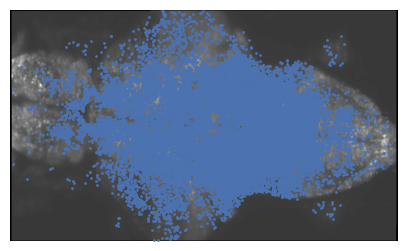

In [3]:
idx_ = cell_subcluster==0
plt.figure(figsize=(5, 3))
plt.imshow(brain_map.max(0), cmap='gray', origin='lower', aspect='auto')
plt.scatter(A_center[idx_, 1], A_center[idx_, 2], s=1)
plt.axis('off')
plt.show()

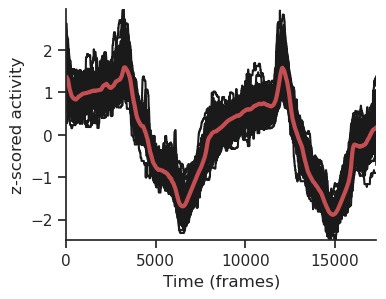

In [4]:
plt.figure(figsize=(4, 3))
plt.plot(zscore(baseline_[idx_][::100].astype('float'), axis=1).T, '-k')
plt.plot(zscore(baseline_[idx_].astype('float'), axis=1).mean(axis=0), '-r', lw=3)
plt.ylabel('z-scored activity')
plt.xlabel('Time (frames)')
plt.margins(0, 0)
sns.despine()
plt.show()